In [1]:
import pandas as pd
import os
os.environ["OMP_NUM_THREADS"] = "9"
os.environ["OMP_NUM_THREADS"] = "9"
df = pd.read_csv(r"C:\Users\Deepika\OneDrive\Desktop\PGP-DSBA\Customer_Personality_Analysis.csv", sep='\t')
df.head

<bound method NDFrame.head of          ID  Year_Birth   Education Marital_Status   Income  Kidhome  \
0      5524        1957  Graduation         Single  58138.0        0   
1      2174        1954  Graduation         Single  46344.0        1   
2      4141        1965  Graduation       Together  71613.0        0   
3      6182        1984  Graduation       Together  26646.0        1   
4      5324        1981         PhD        Married  58293.0        1   
...     ...         ...         ...            ...      ...      ...   
2235  10870        1967  Graduation        Married  61223.0        0   
2236   4001        1946         PhD       Together  64014.0        2   
2237   7270        1981  Graduation       Divorced  56981.0        0   
2238   8235        1956      Master       Together  69245.0        0   
2239   9405        1954         PhD        Married  52869.0        1   

      Teenhome Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  \
0            0  04-09-2012      

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [3]:
df.shape

(2240, 29)

In [4]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [5]:
df['Income'].describe()

count      2216.000000
mean      52247.251354
std       25173.076661
min        1730.000000
25%       35303.000000
50%       51381.500000
75%       68522.000000
max      666666.000000
Name: Income, dtype: float64

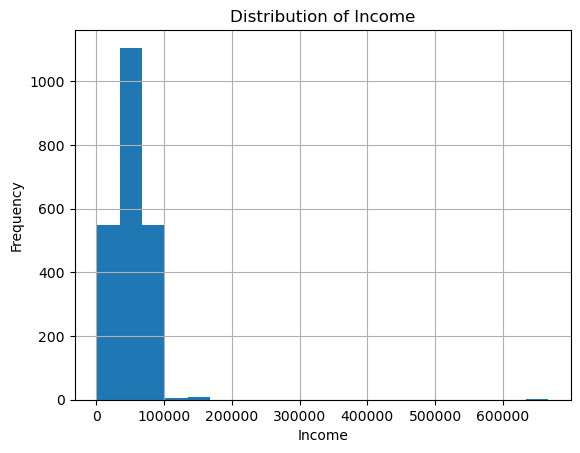

In [6]:
import matplotlib.pyplot as plt
df['Income'].hist(bins=20)

plt.xlabel('Income')
plt.ylabel('Frequency')
plt.title('Distribution of Income')
plt.show()

In [7]:
df = df[df['Income'] <= 600000]

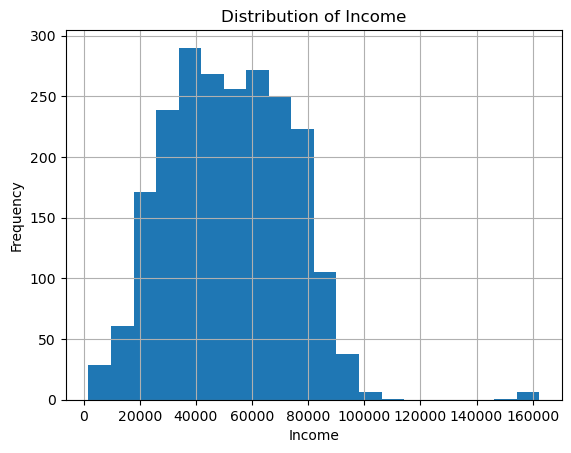

In [8]:
import matplotlib.pyplot as plt
df['Income'].hist(bins=20)

plt.xlabel('Income')
plt.ylabel('Frequency')
plt.title('Distribution of Income')
plt.show()

In [9]:
from sklearn.preprocessing import StandardScaler

# --- Cleaning ---
df = df.dropna(subset=['Income'])          # drop rows with missing income
df = df[df['Income'] < 150000]              # drop the extreme outlier(s)

# --- Feature engineering ---
mnt_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 
            'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df['TotalSpend'] = df[mnt_cols].sum(axis=1)

X = df[['Income', 'TotalSpend']]

# --- Scaling ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

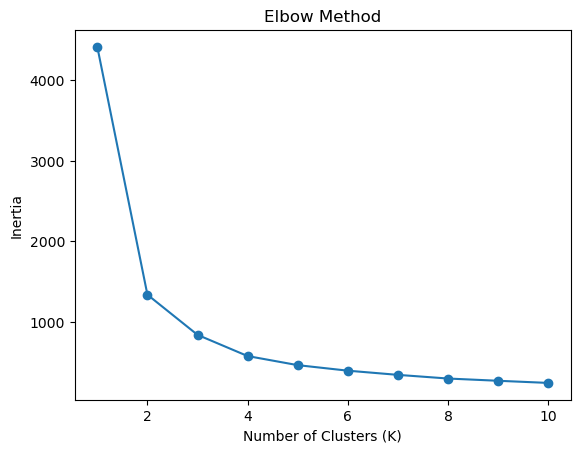

In [10]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.plot(k_range, inertias, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [11]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

In [12]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, df['Cluster'])
print("Silhouette Score:", score)

Silhouette Score: 0.4110946281872038


In [13]:
df.groupby('Cluster')[['Income', 'TotalSpend']].mean()

,Income,TotalSpend
Cluster,,
0,22719.302108,69.714286
1,69493.968153,1042.367304
2,55865.748780,488.000000
3,79534.063291,1703.306962
4,40302.313356,138.585616


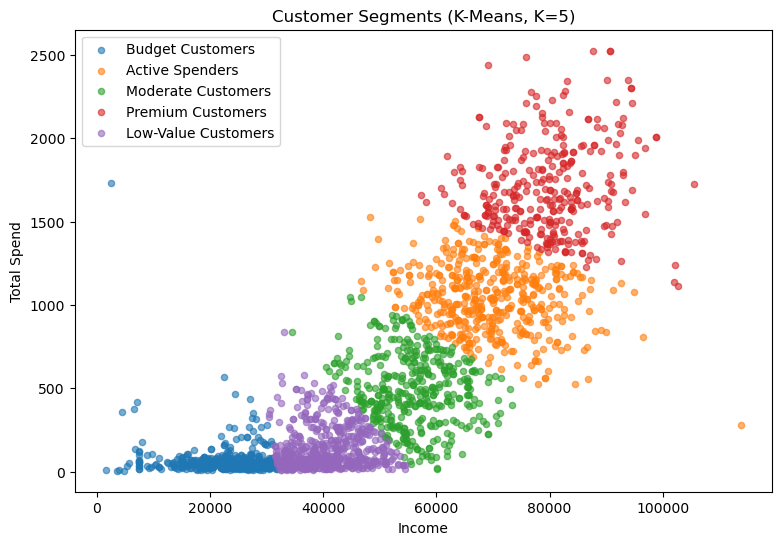

In [14]:
labels = {
    0: 'Budget Customers',
    1: 'Active Spenders',
    2: 'Moderate Customers',
    3: 'Premium Customers',
    4: 'Low-Value Customers'
}
df['Segment'] = df['Cluster'].map(labels)

plt.figure(figsize=(9,6))
for cluster_id, label in labels.items():
    subset = df[df['Cluster'] == cluster_id]
    plt.scatter(subset['Income'], subset['TotalSpend'], label=label, alpha=0.6, s=20)

plt.xlabel('Income')
plt.ylabel('Total Spend')
plt.title('Customer Segments (K-Means, K=5)')
plt.legend()
plt.show()